# Model comparison

Đọc history và metrics do `src.train`/`src.evaluate` tạo ra để so sánh ba mô hình trên cùng split.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS = ROOT / 'artifacts'
MODELS = ['simple_cnn', 'deep_cnn', 'resnet50']

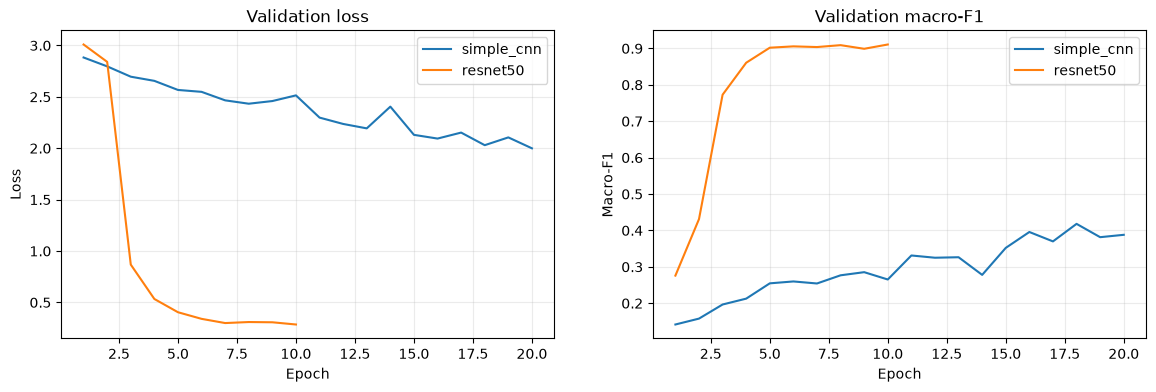

In [2]:
histories = {}
for name in MODELS:
    path = ARTIFACTS / f'{name}_history.json'
    if path.exists():
        histories[name] = pd.DataFrame(json.loads(path.read_text()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, history in histories.items():
    axes[0].plot(history['epoch'], history['val_loss'], label=name)
    axes[1].plot(history['epoch'], history['val_macro_f1'], label=name)
axes[0].set(title='Validation loss', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Validation macro-F1', xlabel='Epoch', ylabel='Macro-F1')
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.show()

In [3]:
rows = []
for name in MODELS:
    path = ARTIFACTS / f'{name}_metrics.json'
    if path.exists():
        metrics = json.loads(path.read_text())
        rows.append({
            'model': name,
            'accuracy': metrics['accuracy'],
            'macro_f1': metrics['macro_f1'],
            'weighted_f1': metrics['weighted_f1'],
            'loss': metrics['loss'],
        })

if rows:
    pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
else:
    print('Chưa có metrics. Hãy chạy train và evaluate trước.')
